<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/L06/cvar_cantileaver_exact_vs_sample_based.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CVaR-constrained design** - of a cantilever beam

**PROBLEM STATEMENT:**

The cantileaver beam in the figure is subject to an uncertain force $F$ at the free end tip. Find the smallest admissible stiffness, $I$ that guarantees a probability of failure not greater than $\alpha$

* 1. **Failure** is defined as the beam tip deflecting beyond a prescribed maximum threshold $\delta_{max}$
* 2. **Objective function**:the stiffness is proportional to the cross-sectional area  material cost.

**Beam deflection model**

The tip deflection of a cantilever beam under a point load $F$ applied at the free end is
$$\delta(I,F)=\frac{F L^3}{3 E I}$$
where:
* $L$: beam length  
* $E$: Young's modulus  
* $I$: second moment of area of the cross-section


The associated performance function is:
$$
g(I,F)=\delta(I,F)-\delta_{\max}.
$$  
* $\delta_{\max}$ maximum allowed deflection at  the tip

$g(I,F)\le 0$ means the design $I$ is safe when we apply force $F$, whilst $g(I,F)>0$ indicates a violation of the deflection limit.



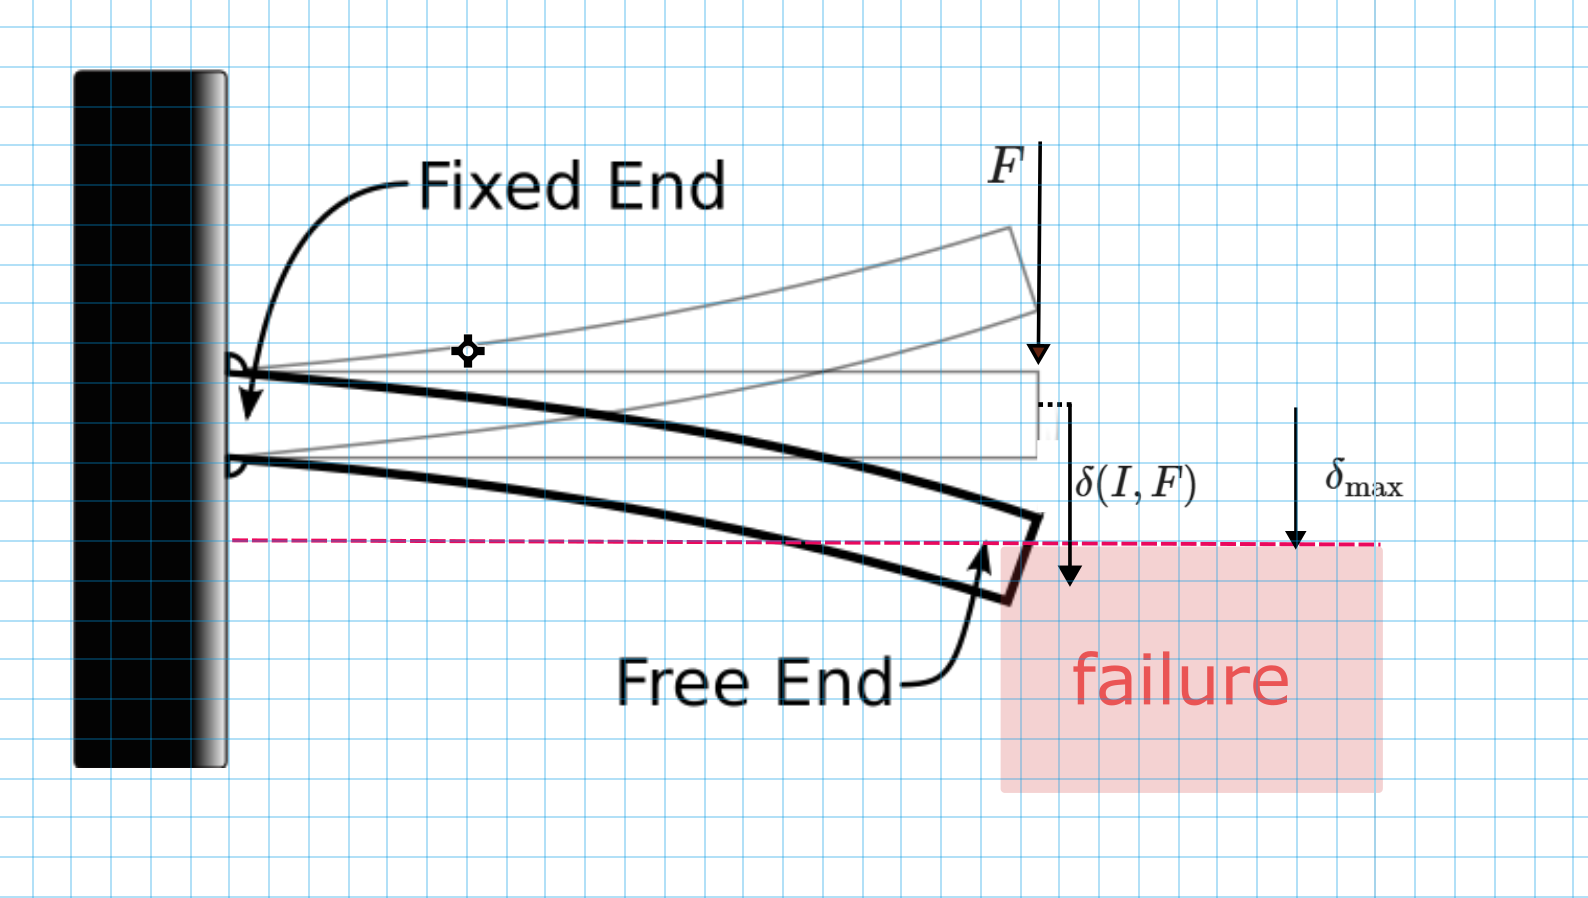


# **The approximated CCP**

For a probability level $\alpha\in (0,1)$, the standard chance constraint can be approximated using the conditional value at risk (CVaR). Because chance constraints are generally non-convex, we replace this with a tractable CVaR upper bound which also sattisfies the chance constraints as follows:
$$
 \mathrm{CVaR}_{\beta}\big(g(I,F)\big)\le 0 ⟹ \mathbb{P}\big(g(I,F)\le 0\big)\ge 1-\alpha
$$
where $\beta=1-\alpha$. so satisfying the CVaR constraint is sufficient for the original probabilistic requirement. The resulting CVaR-constrained optimization problem is:

\begin{aligned}
\min_{I} \quad & I \\
\text{s.t.} \quad & \mathrm{CVaR}_{\beta}\big(g(I,F)\big)\le 0, \\
& I_{\min}\le I\le I_{\max}.
\end{aligned}


This means that the design minimizes stiffness (or weight surrogate) while ensuring that the average of the worst deflection violations remains nonpositive.


In [2]:
import numpy as np
import cvxpy as cp # package for convex optimization
from scipy.stats import norm
from scipy.optimize import minimize # scipy solver

# -----------------------------
# Problem data
L = 2.0 # length
E = 210e9 # elasticity
c = L**3 / (3.0 * E)
delta_max = 0.005 # max displacement
mu_F = 1000.0 # mean value force
sigma_F = 200.0 # standard deviation force
beta = 0.95 # chance constraint probability  1 -\alpha
I_min = 1e-8 # Min bounds on I
I_max = 5e-5 # Max bounds on I

def cvar_g(I):
  a = L**3 / (3.0 * E * I)
  mu = a * mu_F - delta_max
  sigma = a * sigma_F
  return mu + sigma * norm.pdf(norm.ppf(beta)) / (1.0 - beta)



### This Problem i analytically solvable for the Gaussian case
The force is known to be Gaussian distributed with mean and variance $\mu_F,\sigma_F^2$ and therefore also the function $g(I,F)$ is also gaussian distributed with mean and variance $\mu_g(I),\sigma_g^2(I)$ (because the force enters leinearly in the equation of $g$  Tthe transformed mean and variance are:

$$
\mu_g(I)=\frac{L^3}{3EI}\mu_F-\delta_{\max},
\qquad
\sigma_g(I)=\frac{L^3}{3EI}\sigma_F.
$$



The chance constrain can be approximated by $\mathrm{CVaR}_{\beta}(g(I)) \leq 0 $ and the CVaR is computed exactly (Gaussian) as follows:

$$ \mathrm{CVaR}_{\beta}(g(I)) = \mu_g(I)+\sigma_g(I)\frac{\varphi(\Phi^{-1}(\beta))}{1-\beta}$$



At the optimum, the constraint must be **active** (tight $=$ sign) at the minimum for $I$, so we can directly solve for $\mathrm{CVaR}_\beta(g(I)) = 0$:

$$
\frac{L^3}{3EI} \cdot \underbrace{\left(\mu_F + \sigma_F \cdot \frac{\phi\!\left(\Phi^{-1}(\beta)\right)}{1-\beta}\right)}_{C} = \delta_{\max}
$$

which immediately gives the closed-form solution:

$$
I^* = \frac{L^3 \cdot C}{3E \cdot \delta_{\max}}
$$


In [5]:
from scipy.stats import norm
import numpy as np

kappa = norm.pdf(norm.ppf(beta)) / (1.0 - beta)  # this is the safety coefficent
C     = mu_F + sigma_F * kappa   # coefficient from our gaussian model
I_star = (L**3 * C) / (3.0 * E * delta_max) # exact solution
I_star = min(max(I_min, I_star), I_max) # apply bounds on I
print(f"I* = {I_star:.6e}")   # exact, no solver needed
print("CVaR =", cvar_g(I_star))  # ~0 if binding

I* = 3.587410e-06
CVaR = 0.0


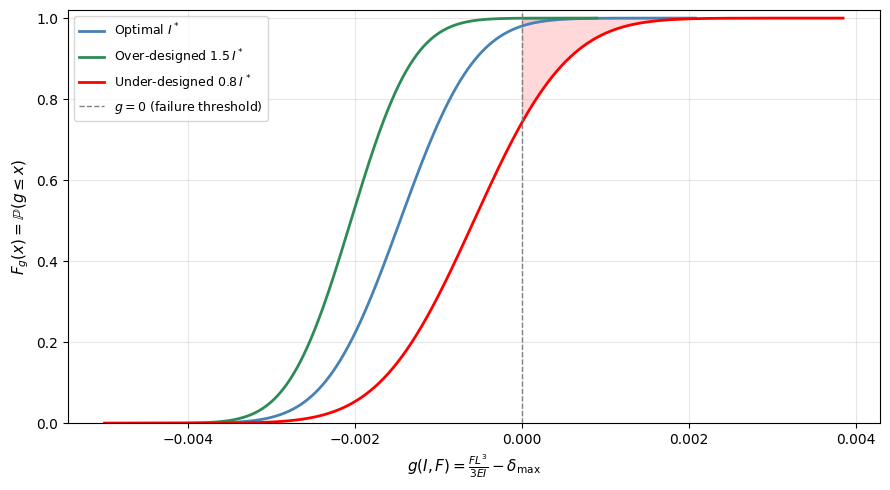

In [6]:
import matplotlib.pyplot as plt
kappa = norm.pdf(norm.ppf(beta)) / (1.0 - beta)
C     = mu_F + sigma_F * kappa
I_star = (L**3 * C) / (3 * E * delta_max)

# --- Two designs to compare ---
I1 = I_star           # optimal: CVaR constraint active
I2 = I_star * 1.2     # over-designed: more conservative
I3 = I_star * 0.8    # under-designed: more conservative
designs = {
    rf"Optimal $I^*$":       I1,
    rf"Over-designed $1.5\,I^*$": I2,
    rf"Under-designed $0.8\,I^*$": I3,
}
colors = ["steelblue", "seagreen", "red"]
# --- Analytical g distribution ---
def g_moments(I):
    a    = L**3 / (3 * E * I)
    mu_g = a * mu_F - delta_max
    sg_g = a * sigma_F
    return mu_g, sg_g

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

for (label, I), color in zip(designs.items(), colors):
    mu_g, sg_g = g_moments(I)
    x = np.linspace(mu_g - 5*sg_g, mu_g + 5*sg_g, 1000)
    cdf = norm.cdf(x, mu_g, sg_g)
    ax.plot(x, cdf, color=color, lw=2, label=label)

    # shade tail P(g > 0)  = failure probability
    x_fail = x[x >= 0]
    if len(x_fail):
        cdf_fail = norm.cdf(x_fail, mu_g, sg_g)
        ax.fill_betweenx(cdf_fail, x_fail, alpha=0.15, color=color)

    # mark P(g=0) = 1 - P_f
    pf = 1 - norm.cdf(0, mu_g, sg_g)

ax.axvline(0, color="gray", lw=1, ls="--", label=r"$g = 0$ (failure threshold)")
ax.set_xlabel(r"$g(I, F) = \frac{FL^3}{3EI} - \delta_{\max}$", fontsize=11)
ax.set_ylabel(r"$F_g(x) = \mathbb{P}(g \leq x)$", fontsize=11)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Reformulation as a Linear Program


* The CVaR constraint has the form:

$$
 \frac{L^3}{3EI}\mu_F - \delta_{\max} + \frac{L^3}{3EI}\sigma_F \cdot \underbrace{\frac{\varphi(\Phi^{-1}(\beta))}{1-\beta}}_{k} \leq 0
$$

Let
* $a = L^3/(3E)$ and
* $c_1 = a(\mu_F + k\sigma_F)$:

$$
\frac{c_1}{I} - \delta_{\max} \leq 0
$$

The term $1/I$ makes this **hyperbolic** (nonlinear) in the decision variable $I$.


---
> **Change of Variable**: $z = 1/I$ the constraint becomes **linear** in $z$:

$$
c_1 \cdot z - \delta_{\max} \leq 0 \quad \Longleftrightarrow \quad c_1 \cdot z \leq \delta_{\max}
$$

$$
I_{\min} \leq I \leq I_{\max}
\quad\Longleftrightarrow\quad
\frac{1}{I_{\max}} \leq z \leq \frac{1}{I_{\min}}
$$

> **Note:** minimizing $I = 1/z$ is equivalent to **maximizing** $z$, which in standard LP form becomes minimizing $-z$.

---
This is a **single-variable LP** solvable with `scipy.optimize.linprog`:
$$
\begin{aligned}
\min_{z} \quad & -z \\
\text{s.t.} \quad & c_1 \cdot z \leq \delta_{\max} \\
& \frac{1}{I_{\max}} \leq z \leq \frac{1}{I_{\min}}
\end{aligned}
$$





In [7]:
from scipy.optimize import linprog
# Your params: L, E, mu_F, sigma_F, delta_max, beta, I_min, I_max
a = L**3 / (3.0 * E)
alpha = norm.ppf(beta)
k = norm.pdf(alpha) / (1 - beta)
c1 = a * (mu_F + k * sigma_F)

z_min = 1 / I_max
z_max = 1 / I_min

c = np.array([-1.0])  # Coefficients: max z
A_ub = np.array([[c1]])  # Shape (1,1): c1 * z <= delta_max
b_ub = np.array([delta_max])
bounds = [(z_min, z_max)]

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')
z_star = res.x[0]
I_star = 1 / z_star
print(f"I* = {I_star:.6e}")   # exact, no solver needed
print("CVaR =", cvar_g(I_star))  # ~0 if binding

I* = 3.587410e-06
CVaR = 0.0


## A minimal example for sample-based approximation

Here is not strictly necessary. But let see how we would approximate this result using $N$ samples from the probabilistic model for the load

 $$F_1,\dots,F_N \sim \mathcal{N}(1000,200^2).$$




The empirical CVaR constraint is approximated by:

$$
\widehat{\mathrm{CVaR}}_{\beta}(g)
=
\min_{\tau\in\mathbb R}
\left\{
\tau+\frac{1}{(1-\beta)N}\sum_{i=1}^N  \max\big(g(I,F_i)-\tau,0\big)
\right\}.
$$



  
We can write the approximated CVaR constrained program by introducing $N$ non-negative slack variables $s_i\ge 0$ and the unconstrained value at risk $\tau$ in the optimization:

$$
\begin{aligned}
\min_{z,\,\eta,\,s_1,\dots,s_N} \quad & -z \qquad \bigl(\Leftrightarrow\;\min\; I = 1/z\bigr) \\[6pt]
\text{s.t.} \quad
& \eta + \frac{1}{(1-\beta)N}\sum_{i=1}^N s_i \leq 0, \\[4pt]
& s_i \geq a F_i z - \delta_{\max} - \eta, \qquad i=1,\dots,N, \\[4pt]
& s_i \geq 0, \qquad i=1,\dots,N, \\[4pt]
& \frac{1}{I_{\max}} \leq z \leq \frac{1}{I_{\min}}, \\[4pt]
& \eta \in \mathbb{R},
\end{aligned}
$$

In [18]:

def solve_CVAR_problem(n_samplesm ,verbose=False):
  # ── Samples ───────────────────────────────────────────────────────────────────
  rng       = np.random.default_rng(42)
  F         = rng.normal(loc=mu_F, scale=sigma_F, size=n_samples) # force samples
  # ── Decision variables ────────────────────────────────────────────────────────
  tau = cp.Variable(nonneg=True)             # tau = 1/I  (a positive)
  eta = cp.Variable()                        # VaR is auxiliary (unconstrained)
  s   = cp.Variable(n_samples, nonneg=True)  # slack variables-> excess per sample

  # ── Sample losses: g_s = a * F_s / I - delta_max = a * F_s * tau - delta_max ─
  g = a * F * tau - delta_max                # shape (n_samples,), affine in tau

  # ── Rockafellar-Uryasev CVaR ≤ 0 reformulation ───────────────────────────────
  # CVaR_β(g) = min_η { η + 1/((1-β)N) Σ [g_s - η]+ }
  # Linearize [g_s - η]+ with slack s_s:
  #   s_s ≥ g_s - η,
  #   s_s ≥ 0   =>  s_s = [g_s - η]+

  constraints = [
      tau >= 1.0 / I_max,
      tau <= 1.0 / I_min,
      s   >= g - eta,                                          # s_s ≥ g_s - η
      eta + cp.sum(s) / ((1.0 - beta) * n_samples) <= 0.0,     # CVaR ≤ 0
  ]

  problem = cp.Problem(cp.Maximize(tau), constraints)
  problem.solve(solver=cp.CLARABEL, verbose=False)

  tau_star = tau.value
  I_star   = 1.0 / tau_star
  g_star   = a * F * tau_star - delta_max
  p_safe   = np.mean(g_star <= 0.0)
  var_beta  = np.quantile(g_star, beta)
  cvar_beta = g_star[g_star >= var_beta].mean()

  ## print the results
  if verbose:
    print(f"---------")
    print(f"NUMBER OF SAMPLES: {n_samples}")
    print(f"Status : {problem.status}")
    print(f"tau*   = {tau_star:.6e}")
    print(f"I*     = {I_star:.6e}")
    print(f"P[g ≤ 0]  = {p_safe:.4f}  (target ≥ {beta})")
    print(f"VaR_{beta}  = {var_beta:.6e}")
    print(f"CVaR_{beta} = {cvar_beta:.6e}  (should be ≈ 0)")

  return cvar_beta, I_star, problem


Nsample_list = range(10,10_000,100)
CVAR, I_opt = [], []
for n_samples in Nsample_list:

  cvar_n, I_opt_n, _ = solve_CVAR_problem(n_samples)
  # save results
  CVAR.append(cvar_n)
  I_opt.append(I_opt_n)


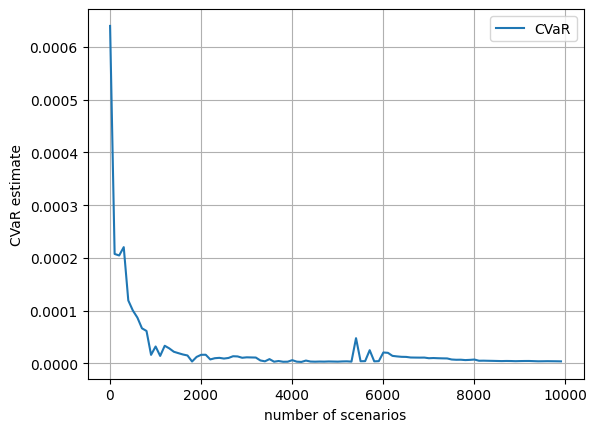

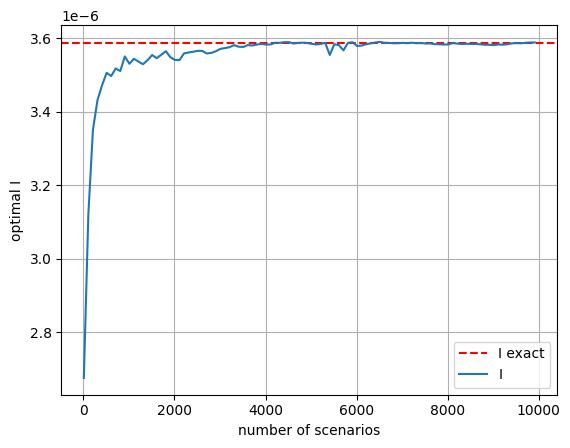

In [19]:
plt.plot(Nsample_list, CVAR, label="CVaR")
plt.xlabel('number of scenarios')
plt.ylabel('CVaR estimate')
plt.grid()
plt.legend()
plt.show()

plt.axhline(y=I_star, color="r", linestyle="--", label="I exact")
plt.plot(Nsample_list, I_opt, label="I")
plt.xlabel('number of scenarios')
plt.ylabel('optimal I')
plt.grid()
plt.legend()
plt.show()